In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('/content/education_career_success.csv')

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_Ranking,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S00001,24,Male,3.58,1052,291,3.96,Arts,3,7,2,9,8,5,27200.0,4,5,Entry,7,No
1,S00002,21,Other,2.52,1211,112,3.63,Law,4,7,3,8,1,4,25000.0,1,1,Mid,7,No
2,S00003,28,Female,3.42,1193,715,2.63,Medicine,4,8,1,1,9,0,42400.0,9,3,Entry,7,No
3,S00004,25,Male,2.43,1497,170,2.81,Computer Science,3,9,1,10,6,1,57400.0,7,5,Mid,5,No
4,S00005,22,Male,2.08,1012,599,2.48,Engineering,4,6,4,10,9,4,47600.0,9,5,Entry,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S04996,26,Female,2.44,1258,776,2.44,Arts,3,7,3,8,5,5,31500.0,9,5,Mid,7,No
4996,S04997,18,Female,3.94,1032,923,3.73,Law,0,9,3,6,4,5,41800.0,9,2,Entry,4,No
4997,S04998,19,Female,3.45,1299,720,2.52,Law,3,5,5,6,2,2,49500.0,2,5,Mid,6,No
4998,S04999,19,Male,2.70,1038,319,3.94,Law,1,4,5,5,1,5,54700.0,9,4,Entry,6,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             5000 non-null   object 
 1   Age                    5000 non-null   int64  
 2   Gender                 5000 non-null   object 
 3   High_School_GPA        5000 non-null   float64
 4   SAT_Score              5000 non-null   int64  
 5   University_Ranking     5000 non-null   int64  
 6   University_GPA         5000 non-null   float64
 7   Field_of_Study         5000 non-null   object 
 8   Internships_Completed  5000 non-null   int64  
 9   Projects_Completed     5000 non-null   int64  
 10  Certifications         5000 non-null   int64  
 11  Soft_Skills_Score      5000 non-null   int64  
 12  Networking_Score       5000 non-null   int64  
 13  Job_Offers             5000 non-null   int64  
 14  Starting_Salary        5000 non-null   float64
 15  Care

In [6]:
df.set_index('Student_ID', inplace=True)

In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
High_School_GPA,0
SAT_Score,0
University_Ranking,0
University_GPA,0
Field_of_Study,0
Internships_Completed,0
Projects_Completed,0
Certifications,0


In [8]:
df[df.duplicated()]

,Age,Gender,High_School_GPA,SAT_Score,University_Ranking,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
Student_ID,,,,,,,,,,,,,,,,,,,


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [10]:
for i in df.select_dtypes(include=["object"]).columns:
  df[i]= encoder.fit_transform(df[i])

In [26]:
df

,Age,Gender,High_School_GPA,SAT_Score,University_Ranking,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
Student_ID,,,,,,,,,,,,,,,,,,,
S00001,24,1,3.58,1052,291,3.96,0,3,7,2,9,8,5,27200.0,4,5,0,7,0
S00002,21,2,2.52,1211,112,3.63,4,4,7,3,8,1,4,25000.0,1,1,2,7,0
S00003,28,0,3.42,1193,715,2.63,6,4,8,1,1,9,0,42400.0,9,3,0,7,0
S00004,25,1,2.43,1497,170,2.81,2,3,9,1,10,6,1,57400.0,7,5,2,5,0
S00005,22,1,2.08,1012,599,2.48,3,4,6,4,10,9,4,47600.0,9,5,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S04996,26,0,2.44,1258,776,2.44,0,3,7,3,8,5,5,31500.0,9,5,2,7,0
S04997,18,0,3.94,1032,923,3.73,4,0,9,3,6,4,5,41800.0,9,2,0,4,0
S04998,19,0,3.45,1299,720,2.52,4,3,5,5,6,2,2,49500.0,2,5,2,6,0


In [14]:
df.groupby('Field_of_Study')['Starting_Salary'].mean()
# the average salary by Field_of_Study

,Starting_Salary
Field_of_Study,
0,51422.830441
1,50262.169680
2,50777.164179
3,50416.547789
4,50081.155433
5,50725.906040
6,50219.158200


In [15]:
df['Entrepreneurship'].value_counts()

,count
Entrepreneurship,
0,3992
1,1008


In [16]:
df[['Projects_Completed', 'Starting_Salary']].corr()


,Projects_Completed,Starting_Salary
Projects_Completed,1.000000,0.015192
Starting_Salary,0.015192,1.000000


In [17]:
df['Current_Job_Level'].value_counts()

,count
Current_Job_Level,
0,2463
2,1544
3,770
1,223


In [18]:
df.groupby('Age')['Starting_Salary'].mean()

,Starting_Salary
Age,
18,50820.971302
19,50459.950249
20,50781.336406
21,50053.694581
22,49438.657407
23,50546.080760
24,49674.111675
25,51724.940048
26,50078.809524


In [19]:
df.groupby('Gender')['Starting_Salary'].mean()

,Starting_Salary
Gender,
0,50536.425532
1,50649.755899
2,49791.666667


In [20]:
df.groupby('Field_of_Study')['Career_Satisfaction'].mean()

,Career_Satisfaction
Field_of_Study,
0,5.607477
1,5.289291
2,5.583582
3,5.512126
4,5.678129
5,5.703356
6,5.667634


In [21]:
df.describe()

,Age,Gender,High_School_GPA,SAT_Score,University_Ranking,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.442200,0.568400,2.996978,1253.832000,504.335600,3.020028,2.985800,1.982200,4.562800,2.512200,5.546000,5.538000,2.488800,50563.540000,5.578000,3.015800,1.124200,5.482400,0.201600
std,3.473712,0.567614,0.575673,203.228954,291.060011,0.576047,2.009877,1.408219,2.872927,1.703183,2.851159,2.850084,1.711859,14494.958207,2.871997,1.417446,1.184168,2.883427,0.401235
min,18.000000,0.000000,2.000000,900.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25000.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,20.000000,0.000000,2.500000,1076.000000,256.000000,2.520000,1.000000,1.000000,2.000000,1.000000,3.000000,3.000000,1.000000,40200.000000,3.000000,2.000000,0.000000,3.000000,0.000000
50%,23.000000,1.000000,2.990000,1257.000000,501.500000,3.030000,3.000000,2.000000,5.000000,3.000000,6.000000,6.000000,2.000000,50300.000000,6.000000,3.000000,1.000000,6.000000,0.000000
75%,26.000000,1.000000,3.500000,1432.000000,759.000000,3.510000,5.000000,3.000000,7.000000,4.000000,8.000000,8.000000,4.000000,60500.000000,8.000000,4.000000,2.000000,8.000000,0.000000
max,29.000000,2.000000,4.000000,1600.000000,1000.000000,4.000000,6.000000,4.000000,9.000000,5.000000,10.000000,10.000000,5.000000,101000.000000,10.000000,5.000000,3.000000,10.000000,1.000000


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

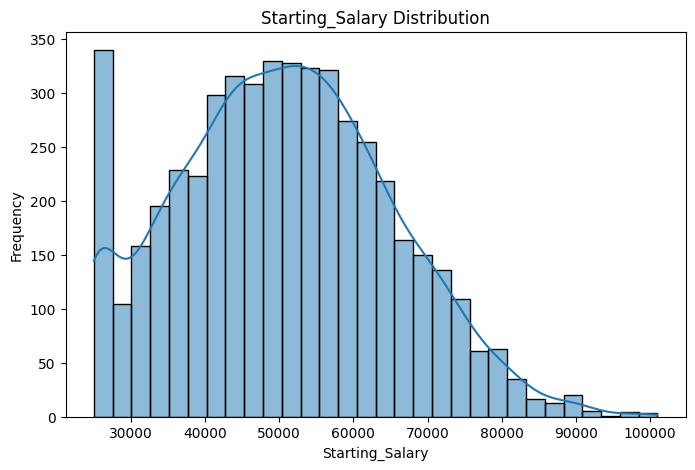

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Starting_Salary'], kde=True, bins=30)
plt.title('Starting_Salary Distribution')
plt.xlabel('Starting_Salary')
plt.ylabel('Frequency')
plt.show()


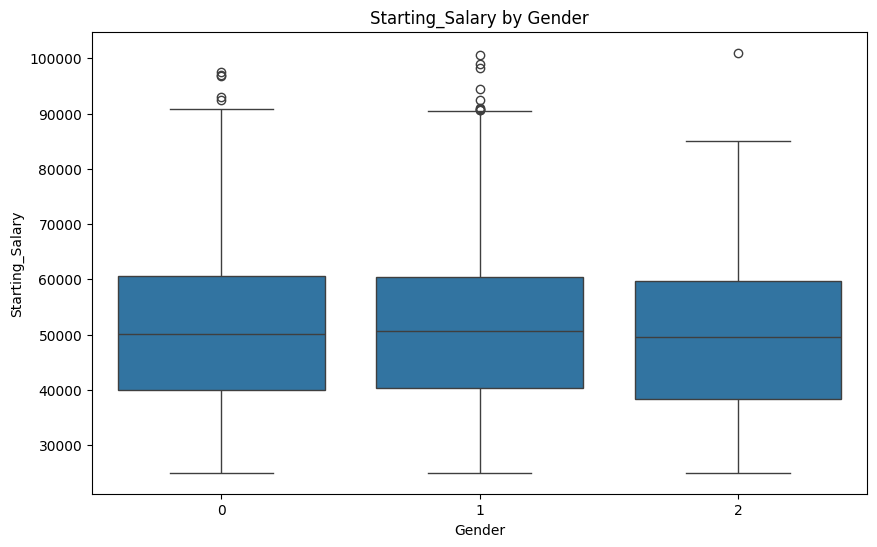

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Starting_Salary', data=df)
plt.title('Starting_Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Starting_Salary')
plt.show()


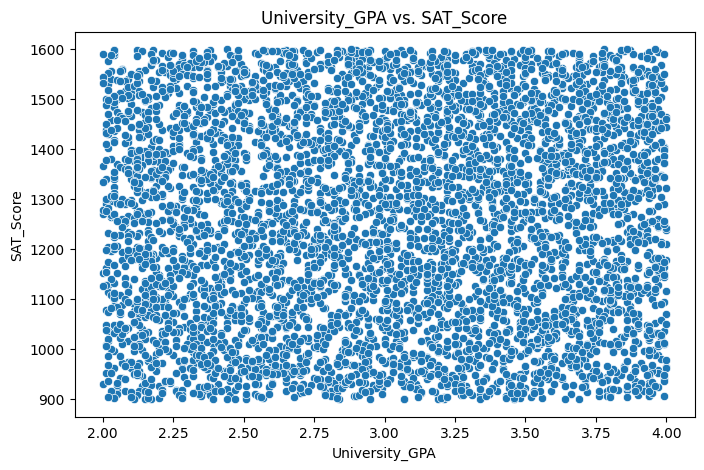

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='University_GPA', y='SAT_Score', data=df)
plt.title('University_GPA vs. SAT_Score')
plt.xlabel('University_GPA')
plt.ylabel('SAT_Score')
plt.show()

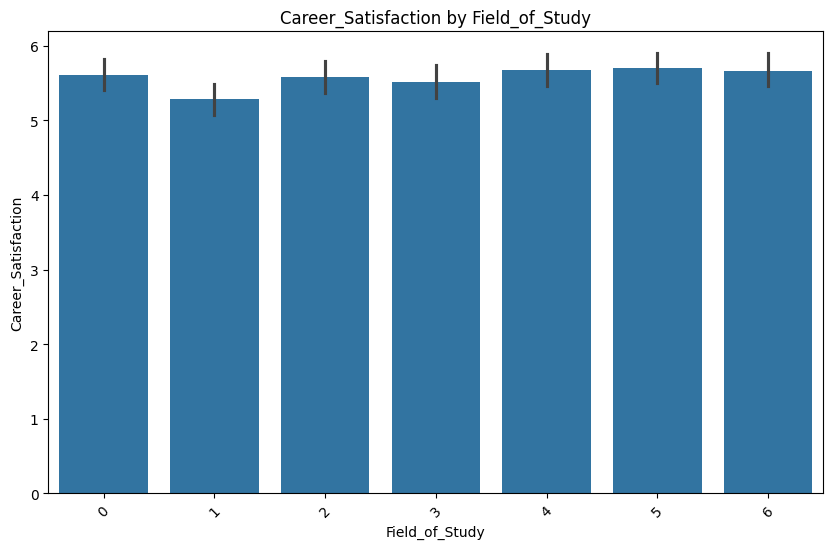

In [33]:
plt.figure(figsize=(10, 6))
avg_satisfaction = df.groupby('Field_of_Study')['Career_Satisfaction'].mean().reset_index()
sns.barplot(x='Field_of_Study', y='Career_Satisfaction', data=df)
plt.title('Career_Satisfaction by Field_of_Study')
plt.xticks(rotation=45)
plt.show()


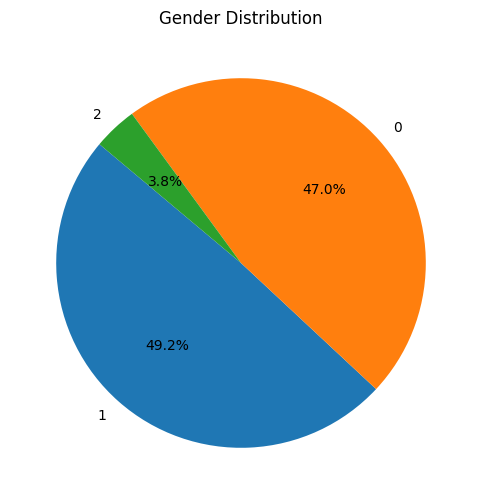

In [34]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution')
plt.show()
